## Student Performance — Model Training Pipeline

**Task**: Predict `math_score`(regression) from reading/writing scores and demographic/socio-economic features.

### 1. Import and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### Load Data and Recreate Engineered Features

- We predict `math_score`. 
- `reading_score` and `writing_score` are used as predictors, along with the
five categorical fields. 
- `total_score`/`average_score` are **excluded** — they're derived directly from `math_score` and would leak the target.

In [2]:
df = pd.read_csv('data/stud.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 8)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
TARGET = 'math_score'

X = df.drop(columns=[TARGET])
y = df[TARGET]

In [4]:
numeric_cols = ['reading_score', 'writing_score']
nominal_cols = ['gender', 'race_ethnicity', 'lunch', 'test_preparation_course']
ordinal_cols = ['parental_level_of_education']

# Explicit ordering for the ordinal feature — reflects a genuine rank, not an arbitrary encoding
edu_order = ["some high school", "high school", "some college", "associate's degree",
             "bachelor's degree", "master's degree"]

print("Numeric features:", numeric_cols)
print("Nominal (one-hot) features:", nominal_cols)
print("Ordinal features:", ordinal_cols)

Numeric features: ['reading_score', 'writing_score']
Nominal (one-hot) features: ['gender', 'race_ethnicity', 'lunch', 'test_preparation_course']
Ordinal features: ['parental_level_of_education']


### Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Train: {X_train.shape[0]} rows\nTest: {X_test.shape[0]} rows")

Train: 800 rows
Test: 200 rows


### Preprocessing Pipeline

A single `ColumnTransformer` handles all three feature types consistently, and is fit only on
`X_train` inside each model's `Pipeline` — this guarantees the same transformation logic is reused
identically for cross-validation, tuning, and final test-set scoring, with zero risk of leakage.

In [6]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('nom', OneHotEncoder(handle_unknown='ignore', drop='first'), nominal_cols),
    ('ord', OrdinalEncoder(categories=[edu_order]), ordinal_cols),
])

# Sanity check: fit-transform on training data and inspect the resulting shape
preview = preprocessor.fit_transform(X_train)
print(f"Transformed feature matrix shape: {preview.shape}")

Transformed feature matrix shape: (800, 10)


In [16]:
check_df = X_train[['parental_level_of_education']].copy()
check_df['encoded_value'] = ord_encoder.transform(X_train[ordinal_cols])
print(check_df.drop_duplicates().sort_values('encoded_value'))

    parental_level_of_education  encoded_value
824            some high school            0.0
836                 high school            1.0
695                some college            2.0
918          associate's degree            3.0
535           bachelor's degree            4.0
29              master's degree            5.0


### Baseline Model

In [18]:
baseline_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
baseline_pipe.fit(X_train, y_train)

y_pred_baseline = baseline_pipe.predict(X_test)
baseline_r2 = r2_score(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

print(f"Baseline Linear Regression — R2: {baseline_r2:.4f}   RMSE: {baseline_rmse:.4f}   MAE: {baseline_mae:.4f}")

Baseline Linear Regression — R2: 0.8816   RMSE: 5.3685   MAE: 4.1820


### Model Comparison via Cross-Validation

Rather than trusting a single train/test split, we use **5-fold cross-validation on the training
set only** to compare candidate algorithms.

In [19]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(random_state=RANDOM_STATE),
    'Lasso': Lasso(random_state=RANDOM_STATE),
    'KNN Regressor': KNeighborsRegressor(),
    'Decision Tree': DecisionTreeRegressor(random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    'AdaBoost': AdaBoostRegressor(random_state=RANDOM_STATE),
    'SVR': SVR(),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, verbosity=0),
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'r2': 'r2', 'neg_rmse': 'neg_root_mean_squared_error', 'neg_mae': 'neg_mean_absolute_error'}

results = []
for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    cv_res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        'model': name,
        'R2_mean': cv_res['test_r2'].mean(), 'R2_std': cv_res['test_r2'].std(),
        'RMSE_mean': -cv_res['test_neg_rmse'].mean(), 'RMSE_std': cv_res['test_neg_rmse'].std(),
        'MAE_mean': -cv_res['test_neg_mae'].mean(),
    })

cv_results_df = pd.DataFrame(results).sort_values('R2_mean', ascending=False).reset_index(drop=True)
cv_results_df

,model,R2_mean,R2_std,RMSE_mean,RMSE_std,MAE_mean
0,Ridge,0.869462,0.014821,5.395636,0.254260,4.330785
1,Linear Regression,0.869385,0.014756,5.397291,0.252478,4.334841
2,Random Forest,0.835363,0.017962,6.058047,0.235332,4.864741
3,AdaBoost,0.819981,0.019793,6.334466,0.234287,5.046574
4,XGBoost,0.807349,0.023685,6.550639,0.305804,5.203268
5,Lasso,0.802500,0.022917,6.635750,0.326416,5.245533
6,KNN Regressor,0.783272,0.025130,6.953834,0.372016,5.534000
7,SVR,0.766760,0.015367,7.231561,0.424753,5.585057
8,Decision Tree,0.701451,0.030822,8.164530,0.394281,6.477500


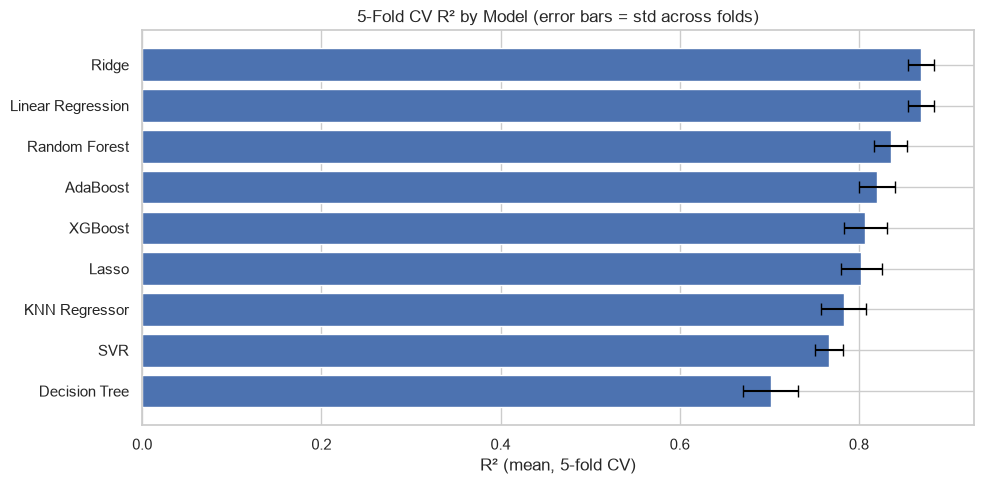

In [20]:
plot_df = cv_results_df.sort_values('R2_mean')
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(plot_df['model'], plot_df['R2_mean'], xerr=plot_df['R2_std'], color='#4C72B0', capsize=4)
ax.set_title('5-Fold CV R² by Model (error bars = std across folds)')
ax.set_xlabel('R² (mean, 5-fold CV)')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning

We tune the top 2 candidates using `GridSearchCV` with the same 5-fold CV, optimizing
for R².

In [21]:
top_2 = cv_results_df.head(2)['model'].tolist()
print("Tuning: ", top_2)

Tuning:  ['Ridge', 'Linear Regression']


In [22]:
param_grids = {
    'Ridge': {'model__alpha': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0]},
    'Lasso': {'model__alpha': [0.001, 0.01, 0.1, 1.0, 5.0]},
    'Linear Regression': {},  # no hyperparameters to tune
    'Random Forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [None, 5, 10, 15],
        'model__min_samples_leaf': [1, 2, 4],
    },
    'XGBoost': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.01, 0.05, 0.1],
    },
    'KNN Regressor': {'model__n_neighbors': [3, 5, 7, 9, 11, 15]},
    'Decision Tree': {'model__max_depth': [3, 5, 8, 12, None], 'model__min_samples_leaf': [1, 2, 4]},
    'SVR': {'model__C': [0.1, 1, 10], 'model__kernel': ['linear', 'rbf']},
    'AdaBoost': {'model__n_estimators': [50, 100, 200], 'model__learning_rate': [0.01, 0.1, 1.0]},
}

tuned_models = {}
for name in top_2:
    grid = param_grids.get(name, {})
    pipe = Pipeline([('preprocessor', preprocessor), ('model', models[name])])
    if grid:
        search = GridSearchCV(pipe, grid, cv=cv, scoring='r2', n_jobs=-1)
        search.fit(X_train, y_train)
        tuned_models[name] = search.best_estimator_
        print(f"{name}: best params = {search.best_params_}   best CV R2 = {search.best_score_:.4f}")
    else:
        pipe.fit(X_train, y_train)
        tuned_models[name] = pipe
        print(f"{name}: no hyperparameters to tune")

Ridge: best params = {'model__alpha': 1.0}   best CV R2 = 0.8695
Linear Regression: no hyperparameters to tune


### Final Evaluation on Held-Out Test Set

In [23]:
final_results = []
for name, pipe in tuned_models.items():
    y_pred = pipe.predict(X_test)
    final_results.append({
        'model': name,
        'test_R2': r2_score(y_test, y_pred),
        'test_RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'test_MAE': mean_absolute_error(y_test, y_pred),
    })

final_results_df = pd.DataFrame(final_results).sort_values('test_R2', ascending=False).reset_index(drop=True)
final_results_df

,model,test_R2,test_RMSE,test_MAE
0,Ridge,0.881565,5.368407,4.183066
1,Linear Regression,0.881560,5.368525,4.181966


In [24]:
best_model_name = final_results_df.iloc[0]['model']
best_model = tuned_models[best_model_name]
print(f"Selected final model: {best_model_name}")
print(final_results_df.iloc[0])

Selected final model: Ridge
model           Ridge
test_R2      0.881565
test_RMSE    5.368407
test_MAE     4.183066
Name: 0, dtype: object


### Residual Analysis

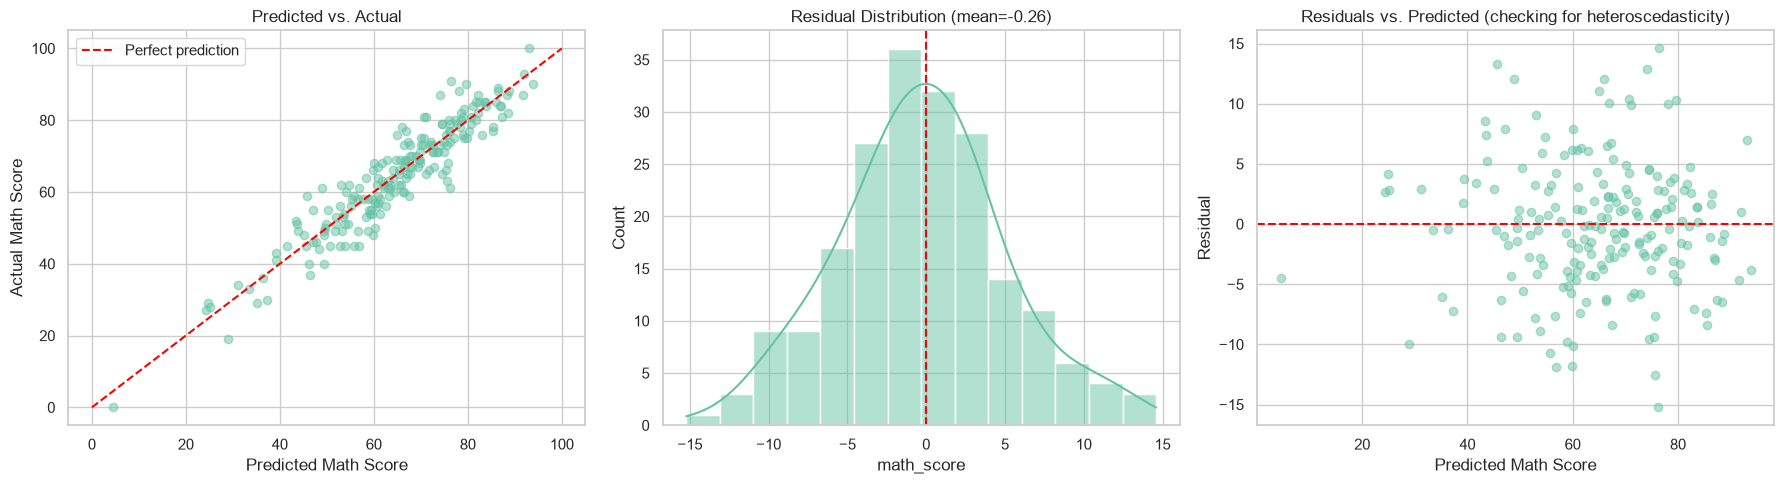

In [25]:
y_pred_final = best_model.predict(X_test)
residuals = y_test - y_pred_final

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].scatter(y_pred_final, y_test, alpha=0.5)
lims = [min(y_test.min(), y_pred_final.min()), max(y_test.max(), y_pred_final.max())]
axs[0].plot(lims, lims, 'r--', label='Perfect prediction')
axs[0].set_xlabel('Predicted Math Score'); axs[0].set_ylabel('Actual Math Score')
axs[0].set_title('Predicted vs. Actual')
axs[0].legend()

sns.histplot(residuals, kde=True, ax=axs[1])
axs[1].axvline(0, color='red', linestyle='--')
axs[1].set_title(f'Residual Distribution (mean={residuals.mean():.2f})')

axs[2].scatter(y_pred_final, residuals, alpha=0.5)
axs[2].axhline(0, color='red', linestyle='--')
axs[2].set_xlabel('Predicted Math Score'); axs[2].set_ylabel('Residual')
axs[2].set_title('Residuals vs. Predicted (checking for heteroscedasticity)')

plt.tight_layout()
plt.show()

**Observation:** Residuals centered near zero with no funnel/curve pattern against
predicted values indicates the model's errors are roughly random rather than systematically biased
for certain score ranges

### Model Persistence

Save the full pipeline (preprocessing + model together) so it can be reloaded and applied to new,
raw data with zero extra transformation code required at inference time.

In [28]:
import os
os.makedirs('artifacts', exist_ok=True)

joblib.dump(best_model, 'artifacts/best_model_pipeline.pkl')
print(f"Saved: artifacts/best_model_pipeline.pkl  ({best_model_name})")

# Reload check
reloaded = joblib.load('artifacts/best_model_pipeline.pkl')
sample_pred = reloaded.predict(X_test.iloc[:5])
print("\nReload sanity check — predictions match:", np.allclose(sample_pred, best_model.predict(X_test.iloc[:5])))

Saved: artifacts/best_model_pipeline.pkl  (Ridge)

Reload sanity check — predictions match: True


In [29]:
# Example: predicting on a brand-new, single student record
new_student = pd.DataFrame([{
    'gender': 'female',
    'race_ethnicity': 'group C',
    'parental_level_of_education': "bachelor's degree",
    'lunch': 'standard',
    'test_preparation_course': 'completed',
    'reading_score': 94,
    'writing_score': 87,
}])

predicted_math_score = reloaded.predict(new_student)[0]
print(f"Predicted math score for the new student: {predicted_math_score:.1f}")

Predicted math score for the new student: 76.8


### What was done
- Built a leakage-safe pipeline: split before preprocessing, preprocessing fit only on training data,
  test set touched exactly once for final evaluation.
- Compared 9 regression algorithms via 5-fold cross-validation rather than a single split.
- Tuned the top 2 candidates with `GridSearchCV`.
- Validated the final model with residual analysis and feature importance, cross-checked against EDA findings.
- Persisted the complete pipeline (preprocessing + model) as a single artifact for reproducible inference.

### Model performance
See `final_results_df` above for the selected model's held-out R², RMSE, and MAE.